In [5]:
import os 
from typing import TypedDict
from dotenv import load_dotenv
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph,START ,END

In [7]:
model = ChatOllama(
model = "llama3.1",
temperature=0
)

In [8]:
class BlogState(TypedDict):
    title : str
    outline : str
    content : str

In [11]:
def create_outline(state: BlogState):
    """frsit AI call generate a blog outline"""
    title = state['title']
    prompt = f"Generate a detailed outline for a blog on the topic {title}"
    response = model.invoke(prompt)
    return{"outline": response.content}

In [10]:
def create_blog(state: BlogState):
    """second AI call: Write the blog based on the title arouns the outline"""
    title = state['title']
    outline = state['outline']
    prompt = f"Write a detailed blog post on the title: '{title} using the following outline :\n{outline}"
    response = model.invoke(prompt)
    return {"content" : response.content}

In [18]:
graph = StateGraph(BlogState)

graph.add_node("create_outline", create_outline)
graph.add_node("create_blog", create_blog)

graph.add_edge(START, "create_outline")
graph.add_edge("create_outline", "create_blog")
graph.add_edge("create_blog", END)

In [20]:
workflow = graph.compile()

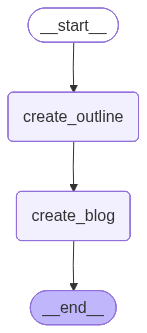

In [21]:
workflow

In [22]:
# Trigger the workflow locally
initial_input = {"title": "The benefits of running AI locally with Ollama"}
final_state = workflow.invoke(initial_input)

# 6. Output Results
print("\n--- FINAL BLOG CONTENT ---")
print(final_state['content'])



--- FINAL BLOG CONTENT ---
**The Benefits of Running AI Locally with Ollama**

Artificial Intelligence (AI) has revolutionized various industries, from healthcare and finance to transportation and education. As AI continues to advance, its importance in our daily lives will only continue to grow. However, the increasing reliance on cloud-based AI processing has raised concerns about latency, security, and flexibility. This is where Ollama comes in – a cutting-edge technology that enables local AI processing, offering numerous benefits for businesses and organizations.

**What is Ollama?**

Ollama is an innovative solution that empowers local AI processing, allowing devices to run complex AI algorithms without relying on cloud-based infrastructure. By leveraging edge computing and AI acceleration capabilities, Ollama reduces latency, enhances security, and increases flexibility in AI applications. With Ollama, organizations can deploy AI models directly on their devices, eliminating th